# Описание датасета

### Набор содержит **более 25 000 изображений** листьев томатов с:  
- 10 типами заболеваний  
- 1 класс здоровых листьев

### Классы:
- Здоровые листья (`healthy`)  
- Поздняя гниль, поздний фитофтороз (`Late_blight`)  
- Ранняя гниль, ранний Фитофтороз (`Early_blight`)  
- Септориоз (`Septorialeafspot`)  
- Вирус желтого курчавтости листьев (`TomatoYellowLeafCurlVirus`)  
- Бактериальная пятнистость (`Bacterial_spot`)  
- Целевая пятнистость (`Target_Spot`)  
- Вирус мозаики томатов (`Tomatomosaicvirus`)  
- Листовая плесень (`Leaf_Mold`)  
- Паутинный клещ (`Spidermites Two-spottedspider_mite`)  
- Мучнистая роса (`Powdery Mildew`)  

# Загрузка датасета и обработка

In [ ]:
import os
from glob import glob
from typing import Tuple
from collections import Counter
import random
import time

import numpy as np
import pandas as pd
from scipy.signal import convolve2d

import cv2
from PIL import Image
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.color import rgb2gray, rgb2hsv, rgb2lab
import pywt

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc
)

from google.colab import drive
import kagglehub
import joblib

In [ ]:
path = kagglehub.dataset_download("ashishmotwani/tomato")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/tomato


# Фильтр Гаусса

In [ ]:
def gaussian_kernel(size: int, sigma: float = 1) -> np.ndarray:
    """Создает гауссово ядро заданного размера."""
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    kernel = np.exp(-((x**2 + y**2) / (2.0 * sigma**2))) * normal
    return kernel / np.sum(kernel)

def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Применяет операцию свёртки к матрице."""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    view = np.lib.stride_tricks.sliding_window_view(padded, (kh, kw))
    output = np.tensordot(view, kernel, axes=((2, 3), (0, 1)))

    return output

def apply_gaussian_blur(image: np.ndarray, kernel_size: int = 5, sigma: float = 1) -> np.ndarray:
    """Применяет гауссово размытие."""
    kernel = gaussian_kernel(kernel_size, sigma)

    output = np.stack([
        convolve2d(image[:, :, c], kernel)
        for c in range(image.shape[2])
    ], axis=2)

    return np.clip(output, 0, 255).astype(np.uint8)

# RGB -> HSV

In [ ]:
def rgb_to_hsv(image: np.ndarray) -> np.ndarray:
    """
    Конвертирует RGB изображение в HSV с масштабированием каналов.
    """
    img = image.astype(np.float32) / 255.0

    Cmax = img.max(axis=2)
    Cmin = img.min(axis=2)
    delta = Cmax - Cmin

    hsv = np.zeros_like(img)

    H = np.zeros_like(Cmax)

    mask = delta != 0

    idx = (img[:, :, 0] == Cmax) & mask
    H[idx] = (60 * ((img[:, :, 1][idx] - img[:, :, 2][idx]) / delta[idx]) + 360) % 360

    idx = (img[:, :, 1] == Cmax) & mask
    H[idx] = (60 * ((img[:, :, 2][idx] - img[:, :, 0][idx]) / delta[idx]) + 120) % 360

    idx = (img[:, :, 2] == Cmax) & mask
    H[idx] = (60 * ((img[:, :, 0][idx] - img[:, :, 1][idx]) / delta[idx]) + 240) % 360

    S = np.where(Cmax != 0, delta / Cmax, 0)

    V = Cmax

    hsv[:, :, 0] = H
    hsv[:, :, 1] = S
    hsv[:, :, 2] = V

    return hsv

# Вейвлет Хаара

In [ ]:
def haar_transform(img):
    """Одномерное преобразование Хаара"""
    n = len(img)
    if n % 2 != 0:
        img = np.append(img, 0)
    avg = (img[::2] + img[1::2]) / np.sqrt(2)
    diff = (img[::2] - img[1::2]) / np.sqrt(2)
    return avg, diff

def haar_2d(image):
    """Двумерное преобразование Хаара"""
    cA_rows = np.zeros((image.shape[0], image.shape[1] // 2))
    cH_rows = np.zeros_like(cA_rows)
    for i in range(image.shape[0]):
        avg, diff = haar_transform(image[i, :])
        cA_rows[i, :] = avg
        cH_rows[i, :] = diff

    cA = np.zeros((image.shape[0] // 2, image.shape[1] // 2))
    cV = np.zeros_like(cA)
    cH = np.zeros_like(cA)
    cD = np.zeros_like(cA)
    for j in range(cA_rows.shape[1]):
        avg, diff = haar_transform(cA_rows[:, j])
        cA[:, j] = avg
        cV[:, j] = diff

        avg, diff = haar_transform(cH_rows[:, j])
        cH[:, j] = avg
        cD[:, j] = diff

    return cA, cH, cV, cD

# Извлечение признаков тренировочного датасета

In [ ]:
RESIZE_TO = (256, 256)
LBP_RADIUS = 3
LBP_POINTS = 8 * LBP_RADIUS
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]

def extract_features(image_path):
    """Извлекает признаки из изображения"""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, RESIZE_TO)
    blurred = apply_gaussian_blur(image)

    gray = rgb2gray(blurred)
    hsv = rgb_to_hsv(blurred)
    lab = rgb2lab(blurred)

    features = []

    ### 1. ЦВЕТОВЫЕ ПРИЗНАКИ
    for channel in range(3):  # R, G, B
        mean = np.mean(blurred[:, :, channel])
        std = np.std(blurred[:, :, channel])
        features.extend([mean, std])

    for channel in range(3):  # H, S, V
        mean = np.mean(hsv[:, :, channel])
        std = np.std(hsv[:, :, channel])
        features.extend([mean, std])

    for channel in range(3):  # L, A, B
        mean = np.mean(lab[:, :, channel])
        std = np.std(lab[:, :, channel])
        features.extend([mean, std])

    ### 2. ВЕЙВЛЕТ-ПРИЗНАКИ
    cA, cH, cV, cD = haar_2d(gray)
    for name, coeff in zip(["cA", "cH", "cV", "cD"], [cA, cH, cV, cD]):
        features.extend([
            np.mean(coeff),
            np.std(coeff),
            np.max(coeff),
            np.min(coeff)
        ])

    ### 3. ТЕКСТУРА (GLCM)
    glcm = graycomatrix(
        (gray * 255).astype(np.uint8),
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=256,
        symmetric=True
    )
    texture_features = []
    for prop in ["contrast", "energy", "homogeneity", "correlation"]:
        texture_features.extend(graycoprops(glcm, prop).ravel())
    features.extend(texture_features)

    ### 4. LBP (Local Binary Patterns)
    lbp = local_binary_pattern(gray, P=LBP_POINTS, R=LBP_RADIUS, method="uniform")
    hist, _ = np.histogram(lbp, bins=20, range=(0, LBP_POINTS + 2))
    hist = hist.astype("float") / (hist.sum() + 1e-7)
    features.extend(hist)

    ### 5. ГИСТОГРАММЫ (RGB)
    for channel in range(3):
        hist = cv2.calcHist([blurred], [channel], None, [16], [0, 256]).flatten()
        hist = hist / (hist.sum() + 1e-7)
        features.extend(hist)

    return features

In [ ]:
dataset_path = path + "/train"
classes = ["healthy", "Bacterial_spot", "Early_blight", "Late_blight", "Leaf_Mold",
           "Septoria_leaf_spot", "Spider_mites Two-spotted_spider_mite",
           "Target_Spot", "Tomato_Yellow_Leaf_Curl_Virus", "Tomato_mosaic_virus",
           "powdery_mildew"]

class_to_label = {clas: i for i, clas in enumerate(classes)}

data = []
labels = []

start_time = time.time()

for class_name in classes:
    image_paths = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        image_paths.extend(glob(os.path.join(dataset_path, class_name, ext)))

    for path in image_paths:
        features = extract_features(path)
        if features is not None:
            data.append(features)
            labels.append(class_to_label[class_name])

end_time = time.time()

columns = [
    "R_mean", "R_std", "G_mean", "G_std", "B_mean", "B_std",
    "H_mean", "H_std", "S_mean", "S_std", "V_mean", "V_std",
    "L_mean", "L_std", "A_mean", "A_std", "B_mean", "B_std",
    *[f"Haar_{stat}_{param}" for param in ["cA", "cH", "cV", "cD"]
                       for stat in ["mean", "std", "max", "min"]],
    *[f"GLCM_{i}" for i in range(16)],
    *[f"LBP_{i}" for i in range(20)],
    *[f"Hist_R_{i}" for i in range(16)],
    *[f"Hist_G_{i}" for i in range(16)],
    *[f"Hist_B_{i}" for i in range(16)],
]

df = pd.DataFrame(data, columns=columns)
df["label"] = labels
df.to_csv("my_tomato_leaves_features_train.csv", index=False)

In [ ]:
execution_time = end_time - start_time
print(f"Время извлечения признаков: {execution_time:.4f} секунд")

Время извлечения признаков: 5508.2138 секунд


In [ ]:
drive.mount("/content/drive")

df.to_csv("/content/drive/My Drive/my_tomato_leaves_features_train.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,R_mean,R_std,G_mean,G_std,B_mean,B_std,H_mean,H_std,S_mean,S_std,...,Hist_B_7,Hist_B_8,Hist_B_9,Hist_B_10,Hist_B_11,Hist_B_12,Hist_B_13,Hist_B_14,Hist_B_15,label
0,126.278183,48.324338,146.723114,55.024521,113.326736,46.440587,127.689407,82.888138,0.256869,0.147605,...,0.123642,0.130081,0.111267,0.079987,0.033691,0.021439,0.012100,0.005661,0.004303,0
1,126.845795,47.268586,144.611542,50.916921,110.947845,45.242755,92.504440,62.946487,0.255952,0.194028,...,0.119354,0.072754,0.043716,0.048050,0.091156,0.045792,0.004990,0.000000,0.000000,0
2,101.761383,54.440132,139.510956,64.873864,103.495819,63.426177,121.235657,27.395357,0.378721,0.177552,...,0.084457,0.081024,0.085571,0.074173,0.070847,0.060043,0.027481,0.003082,0.001236,0
3,144.843292,47.291154,193.577759,50.588588,152.381470,55.246104,130.637390,20.390171,0.275443,0.098123,...,0.084625,0.090134,0.081100,0.091446,0.087738,0.080078,0.066574,0.064743,0.066833,0
4,109.302383,50.661887,144.085175,59.430154,113.789352,56.031025,126.409103,41.873512,0.312773,0.155095,...,0.110947,0.110901,0.103561,0.099518,0.061584,0.033188,0.017899,0.010300,0.006302,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25846,108.748001,59.912565,141.820877,59.783037,98.508163,62.727705,105.213699,21.780233,0.372311,0.183389,...,0.085297,0.098358,0.079605,0.033508,0.007095,0.005722,0.010239,0.012039,0.059219,10
25847,96.780304,29.816237,134.629654,34.940313,89.846863,33.778267,112.848427,16.543341,0.354388,0.110253,...,0.174759,0.063110,0.019333,0.013229,0.007538,0.003372,0.000595,0.000351,0.000610,10
25848,114.207916,27.286118,168.936050,30.415157,124.384354,32.372952,122.547180,35.644394,0.373602,0.090280,...,0.130127,0.194061,0.211533,0.107330,0.016693,0.002106,0.000214,0.000000,0.000000,10
25849,122.323700,27.159625,151.269165,21.799632,121.941040,30.336553,126.703201,40.479977,0.264200,0.097735,...,0.213074,0.246979,0.152237,0.048508,0.021240,0.005020,0.001022,0.000259,0.000061,10


# Извлечение признаков валидационного датасета

In [ ]:
path = kagglehub.dataset_download("ashishmotwani/tomato")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/tomato


In [ ]:
dataset_path = path + "/valid"
classes = ["healthy", "Bacterial_spot", "Early_blight", "Late_blight", "Leaf_Mold",
           "Septoria_leaf_spot", "Spider_mites Two-spotted_spider_mite",
           "Target_Spot", "Tomato_Yellow_Leaf_Curl_Virus", "Tomato_mosaic_virus",
           "powdery_mildew"]

class_to_label = {clas: i for i, clas in enumerate(classes)}

data = []
labels = []

start_time = time.time()

for class_name in classes:
    image_paths = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        image_paths.extend(glob(os.path.join(dataset_path, class_name, ext)))

    for path in image_paths:
        features = extract_features(path)
        if features is not None:
            data.append(features)
            labels.append(class_to_label[class_name])

end_time = time.time()

columns = [
    "R_mean", "R_std", "G_mean", "G_std", "B_mean", "B_std",
    "H_mean", "H_std", "S_mean", "S_std", "V_mean", "V_std",
    "L_mean", "L_std", "A_mean", "A_std", "B_mean", "B_std",
    *[f"Haar_{stat}_{param}" for param in ["cA", "cH", "cV", "cD"]
                       for stat in ["mean", "std", "max", "min"]],
    *[f"GLCM_{i}" for i in range(16)],
    *[f"LBP_{i}" for i in range(20)],
    *[f"Hist_R_{i}" for i in range(16)],
    *[f"Hist_G_{i}" for i in range(16)],
    *[f"Hist_B_{i}" for i in range(16)],
]

df = pd.DataFrame(data, columns=columns)
df["label"] = labels
df.to_csv("my_tomato_leaves_features_valid.csv", index=False)

In [ ]:
execution_time = end_time - start_time
print(f"Время извлечения признаков: {execution_time:.4f} секунд")

Время извлечения признаков: 1435.1622 секунд


In [ ]:
drive.mount("/content/drive")

df.to_csv("/content/drive/My Drive/my_tomato_leaves_features_valid.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,R_mean,R_std,G_mean,G_std,B_mean,B_std,H_mean,H_std,S_mean,S_std,...,Hist_B_7,Hist_B_8,Hist_B_9,Hist_B_10,Hist_B_11,Hist_B_12,Hist_B_13,Hist_B_14,Hist_B_15,label
0,109.372894,50.731385,144.051483,59.386363,113.824585,56.220062,126.348785,42.777603,0.312475,0.155319,...,0.108826,0.107773,0.104218,0.100739,0.062515,0.032410,0.018066,0.010696,0.006577,0
1,176.417801,47.974594,193.920898,48.547278,146.468338,49.735008,70.906960,36.602005,0.250159,0.178531,...,0.116180,0.094131,0.088745,0.089798,0.090027,0.090607,0.088837,0.040131,0.014481,0
2,127.946915,50.738116,143.060059,51.335736,110.787399,49.871122,130.914978,93.360596,0.271884,0.185043,...,0.112671,0.122955,0.112015,0.083069,0.050797,0.021927,0.011917,0.003784,0.001328,0
3,151.972748,51.613428,176.154678,52.444268,142.741653,50.947054,112.113556,59.157478,0.210658,0.133555,...,0.106674,0.125809,0.129868,0.116028,0.056534,0.032944,0.029266,0.031235,0.070801,0
4,99.929245,44.973218,135.521439,53.426558,97.105591,54.459697,114.599304,35.191921,0.390725,0.140189,...,0.088531,0.077957,0.070618,0.060745,0.047089,0.029388,0.010361,0.004044,0.005173,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6678,71.384048,63.961712,74.643646,66.619119,61.435837,50.791655,150.269714,91.409050,0.299188,0.113285,...,0.134308,0.082077,0.019302,0.003738,0.000488,0.000000,0.000000,0.000000,0.000000,10
6679,84.771683,38.470884,117.506470,47.718264,117.571518,53.602866,158.361450,46.579353,0.323342,0.123597,...,0.097916,0.110901,0.127930,0.077118,0.049911,0.038498,0.028214,0.020706,0.005920,10
6680,141.235046,66.186181,131.791061,58.433914,106.718445,59.507630,73.904037,75.474800,0.316499,0.205522,...,0.087769,0.066223,0.064255,0.070587,0.040009,0.023392,0.026291,0.040573,0.007401,10
6681,113.229294,40.769125,124.520782,42.922800,97.656036,42.243161,89.207123,36.476086,0.240059,0.130331,...,0.162888,0.093246,0.051407,0.025452,0.016693,0.009247,0.003265,0.001404,0.004196,10


In [ ]:
df[["Haar_mean_cA", "Haar_std_cA", "Haar_max_cA", "Haar_min_cA"]]

,Haar_mean_cA,Haar_std_cA,Haar_max_cA,Haar_min_cA
0,1.054925,0.439694,1.980649,0.038658
1,1.464942,0.363448,1.992157,0.442736
2,1.078601,0.387067,1.988764,0.019310
3,1.322407,0.394093,1.992157,0.393564
4,0.981869,0.394685,1.973663,0.039904
...,...,...,...,...
6678,0.572539,0.506791,1.600766,0.020452
6679,0.867098,0.352479,1.935571,0.244716
6680,1.035217,0.449895,1.955420,0.086128
6681,0.942623,0.328387,1.991740,0.080378


# Обучение моделей

In [ ]:
drive.mount("/content/drive")

os.makedirs("/content/drive/My Drive/models/", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path_train = "/content/drive/My Drive/my_tomato_leaves_features_train.csv"

file_path_valid = "/content/drive/My Drive/my_tomato_leaves_features_valid.csv"

# Бинарная классификация

In [ ]:
def evaluate_model_binary(model, X_test, y_test, model_name="Model"):
    """Оценка модели"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # 1. Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Здоровый", "Больной"],
                yticklabels=["Здоровый", "Больной"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Истинный класс")
    plt.xlabel("Предсказанный класс")
    plt.show()

    # 2. Отчет по метрикам
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Здоровый", "Больной"]))

    # 3. ROC-AUC
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.3f}")

    # 4. Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.legend()
    plt.show()

Random Forest Evaluation:


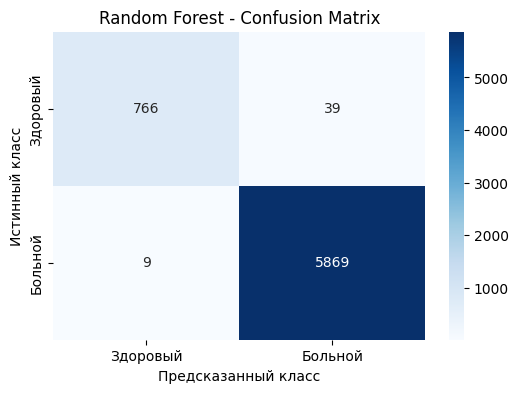


Random Forest Classification Report:
              precision    recall  f1-score   support

    Здоровый       0.99      0.95      0.97       805
     Больной       0.99      1.00      1.00      5878

    accuracy                           0.99      6683
   macro avg       0.99      0.98      0.98      6683
weighted avg       0.99      0.99      0.99      6683

ROC-AUC Score: 0.998


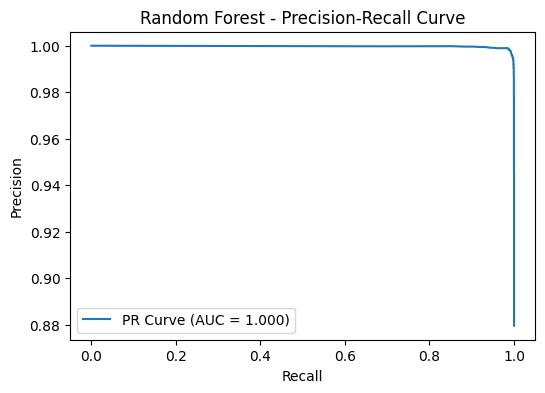


MLP Evaluation:


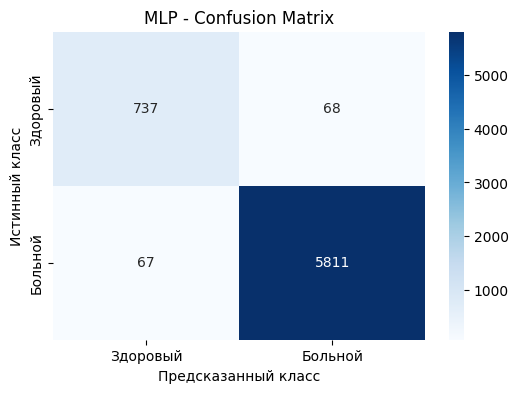


MLP Classification Report:
              precision    recall  f1-score   support

    Здоровый       0.92      0.92      0.92       805
     Больной       0.99      0.99      0.99      5878

    accuracy                           0.98      6683
   macro avg       0.95      0.95      0.95      6683
weighted avg       0.98      0.98      0.98      6683

ROC-AUC Score: 0.993


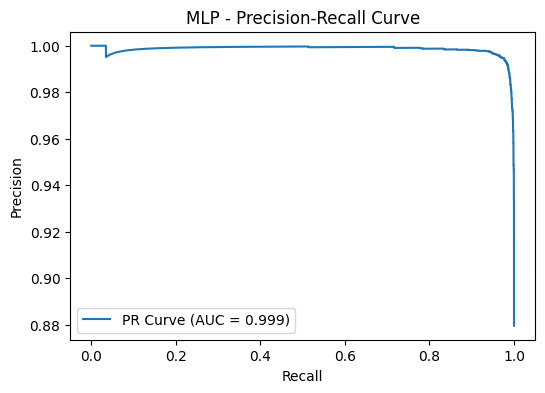

In [ ]:
df = pd.read_csv(file_path_train)
df["label"] = df["label"].apply(lambda x: 1 if x != 0 else 0)
X_train = df.drop("label", axis=1)
y_train = df["label"]

df = pd.read_csv(file_path_valid)
df["label"] = df["label"].apply(lambda x: 1 if x != 0 else 0)
X_test = df.drop("label", axis=1)
y_test = df["label"]

# Обучение Random Forest
rf_binary = RandomForestClassifier(n_estimators=100, random_state=2025)
rf_binary.fit(X_train, y_train)
joblib.dump(rf_binary, "/content/drive/My Drive/models/my_rf_binary.pkl")
print("Random Forest Evaluation:")
evaluate_model_binary(rf_binary, X_test, y_test, "Random Forest")

#Обучение MLP (требует predict_proba)
mlp_binary = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=2025)
mlp_binary.fit(X_train, y_train)
joblib.dump(mlp_binary, "/content/drive/My Drive/models/my_mlp_binary.pkl")
print("\nMLP Evaluation:")
evaluate_model_binary(mlp_binary, X_test, y_test, "MLP")

# Классификация больных

In [ ]:
classes = ["Bacterial_spot", "Early_blight", "Late_blight", "Leaf_Mold",
           "Septoria_leaf_spot", "Spider_mites Two-spotted_spider_mite",
           "Target_Spot", "Tomato_Yellow_Leaf_Curl_Virus", "Tomato_mosaic_virus",
           "powdery_mildew"]

def evaluate_model_sick(model, X_test, y_test, model_name="Model", classes=classes):
    """Оценка модели для многоклассовой классификации"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # 1. Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Истинный класс")
    plt.xlabel("Предсказанный класс")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    # 2. Отчет по метрикам
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))

    # 3. ROC-AUC (One-vs-Rest для многоклассового случая)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
    print(f"ROC-AUC Score (OvR): {roc_auc:.3f}")

Random Forest Evaluation:


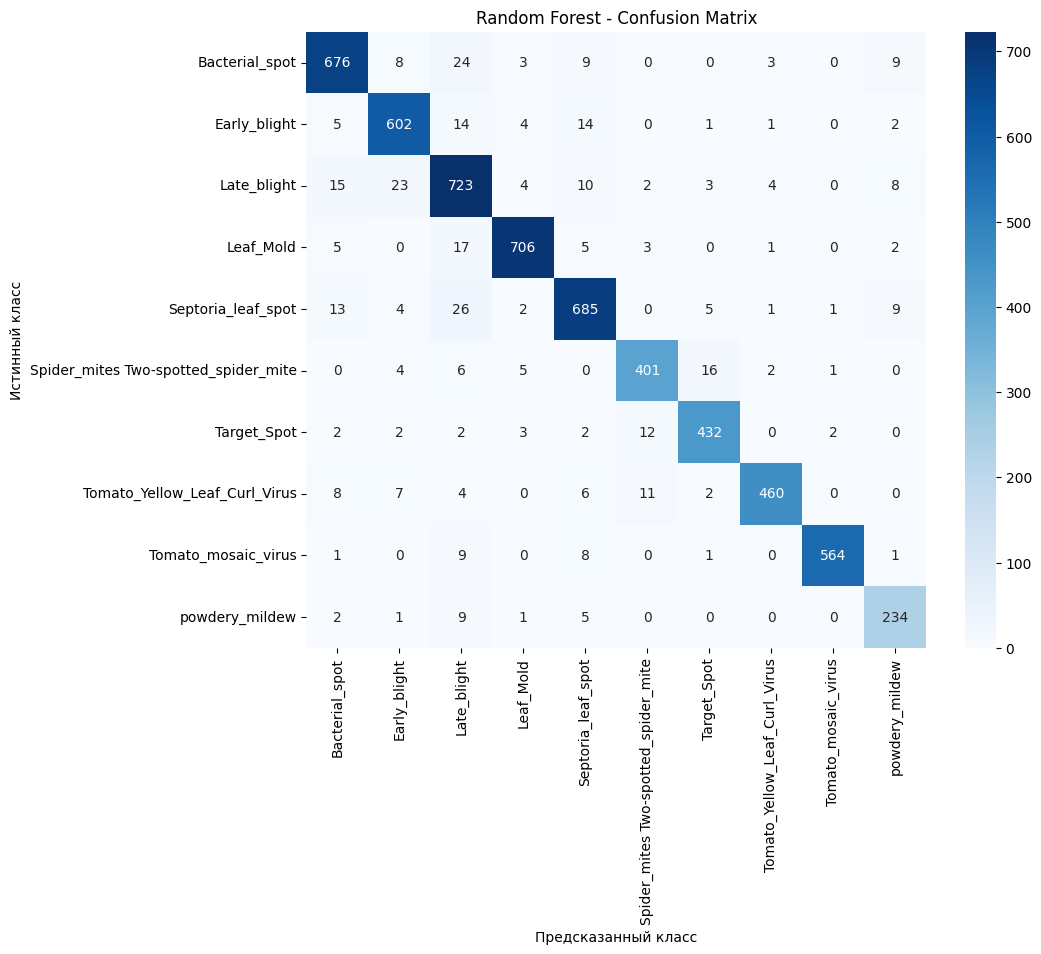


Random Forest Classification Report:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.93      0.92      0.93       732
                        Early_blight       0.92      0.94      0.93       643
                         Late_blight       0.87      0.91      0.89       792
                           Leaf_Mold       0.97      0.96      0.96       739
                  Septoria_leaf_spot       0.92      0.92      0.92       746
Spider_mites Two-spotted_spider_mite       0.93      0.92      0.93       435
                         Target_Spot       0.94      0.95      0.94       457
       Tomato_Yellow_Leaf_Curl_Virus       0.97      0.92      0.95       498
                 Tomato_mosaic_virus       0.99      0.97      0.98       584
                      powdery_mildew       0.88      0.93      0.91       252

                            accuracy                           0.93      5878
                        

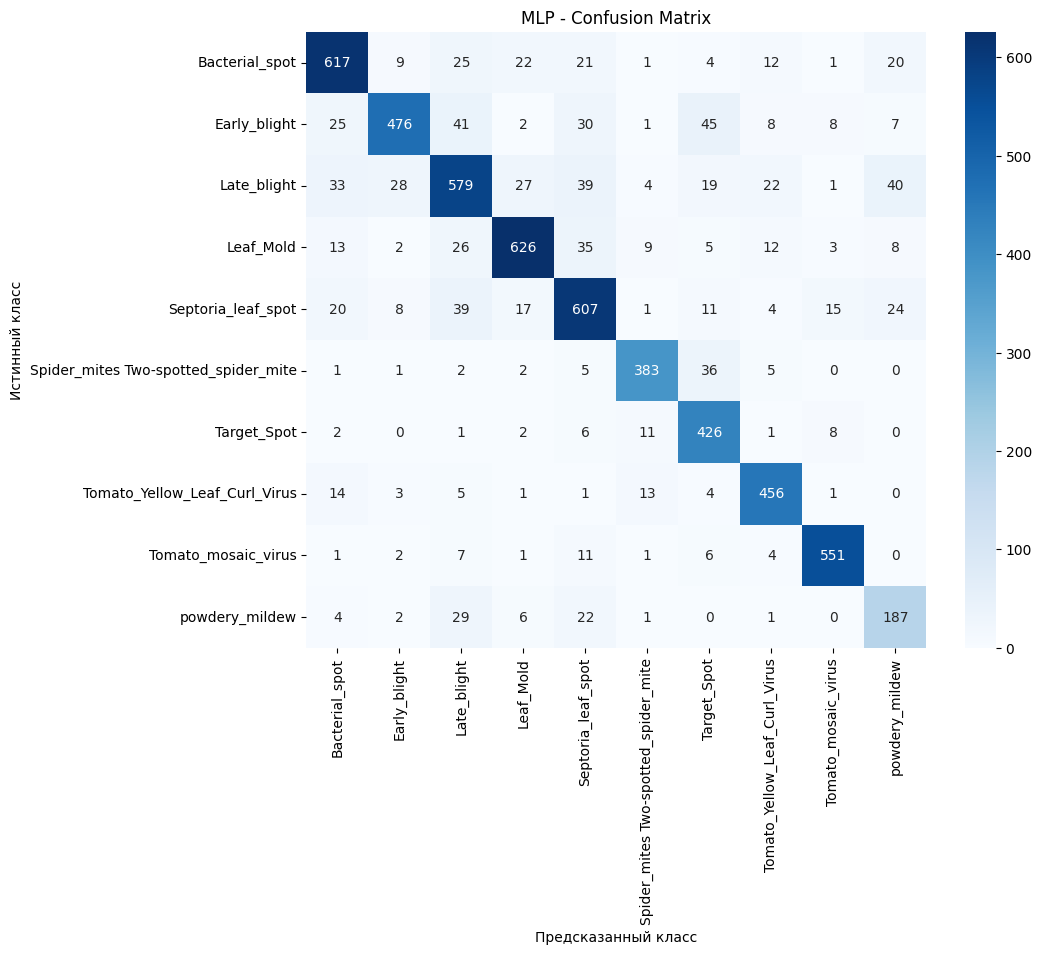


MLP Classification Report:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.85      0.84      0.84       732
                        Early_blight       0.90      0.74      0.81       643
                         Late_blight       0.77      0.73      0.75       792
                           Leaf_Mold       0.89      0.85      0.87       739
                  Septoria_leaf_spot       0.78      0.81      0.80       746
Spider_mites Two-spotted_spider_mite       0.90      0.88      0.89       435
                         Target_Spot       0.77      0.93      0.84       457
       Tomato_Yellow_Leaf_Curl_Virus       0.87      0.92      0.89       498
                 Tomato_mosaic_virus       0.94      0.94      0.94       584
                      powdery_mildew       0.65      0.74      0.70       252

                            accuracy                           0.83      5878
                           macro a

In [ ]:
df = pd.read_csv(file_path_train)
df = df[df["label"] != 0]
X_train = df.drop("label", axis=1)
y_train = df["label"]

df = pd.read_csv(file_path_valid)
df = df[df["label"] != 0]
X_test = df.drop("label", axis=1)
y_test = df["label"]

# Обучение Random Forest
rf_sick = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=2025)
rf_sick.fit(X_train, y_train)
joblib.dump(rf_sick, "/content/drive/My Drive/models/my_rf_sick.pkl")
print("Random Forest Evaluation:")
evaluate_model_sick(rf_sick, X_test, y_test, "Random Forest")

# Обучение MLP
mlp_sick = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=2025)
mlp_sick.fit(X_train, y_train)
joblib.dump(mlp_sick, "/content/drive/My Drive/models/my_mlp_sick.pkl")
print("\nMLP Evaluation:")
evaluate_model_sick(mlp_sick, X_test, y_test, "MLP")

# Многоклассовая классификация

In [ ]:
classes = ["Healthy", "Bacterial_spot", "Early_blight", "Late_blight", "Leaf_Mold",
           "Septoria_leaf_spot", "Spider_mites Two-spotted_spider_mite",
           "Target_Spot", "Tomato_Yellow_Leaf_Curl_Virus", "Tomato_mosaic_virus",
           "powdery_mildew"]

def evaluate_model_all(model, X_test, y_test, model_name="Model", classes=classes):
    """Оценка модели для многоклассовой классификации"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # 1. Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Истинный класс")
    plt.xlabel("Предсказанный класс")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    # 2. Отчет по метрикам
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))

    # 3. ROC-AUC (One-vs-Rest для многоклассового случая)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
    print(f"ROC-AUC Score (OvR): {roc_auc:.3f}")

Random Forest Evaluation:


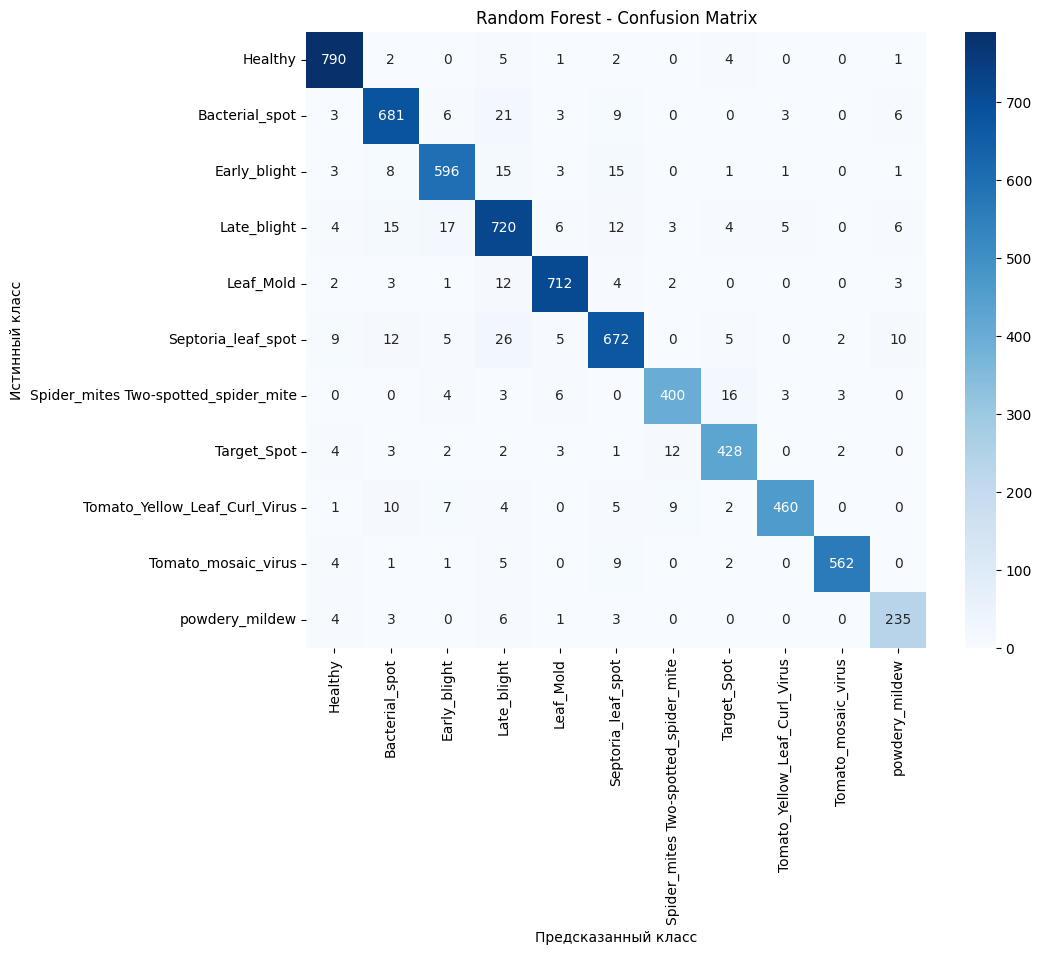


Random Forest Classification Report:
                                      precision    recall  f1-score   support

                             Healthy       0.96      0.98      0.97       805
                      Bacterial_spot       0.92      0.93      0.93       732
                        Early_blight       0.93      0.93      0.93       643
                         Late_blight       0.88      0.91      0.89       792
                           Leaf_Mold       0.96      0.96      0.96       739
                  Septoria_leaf_spot       0.92      0.90      0.91       746
Spider_mites Two-spotted_spider_mite       0.94      0.92      0.93       435
                         Target_Spot       0.93      0.94      0.93       457
       Tomato_Yellow_Leaf_Curl_Virus       0.97      0.92      0.95       498
                 Tomato_mosaic_virus       0.99      0.96      0.97       584
                      powdery_mildew       0.90      0.93      0.91       252

                        

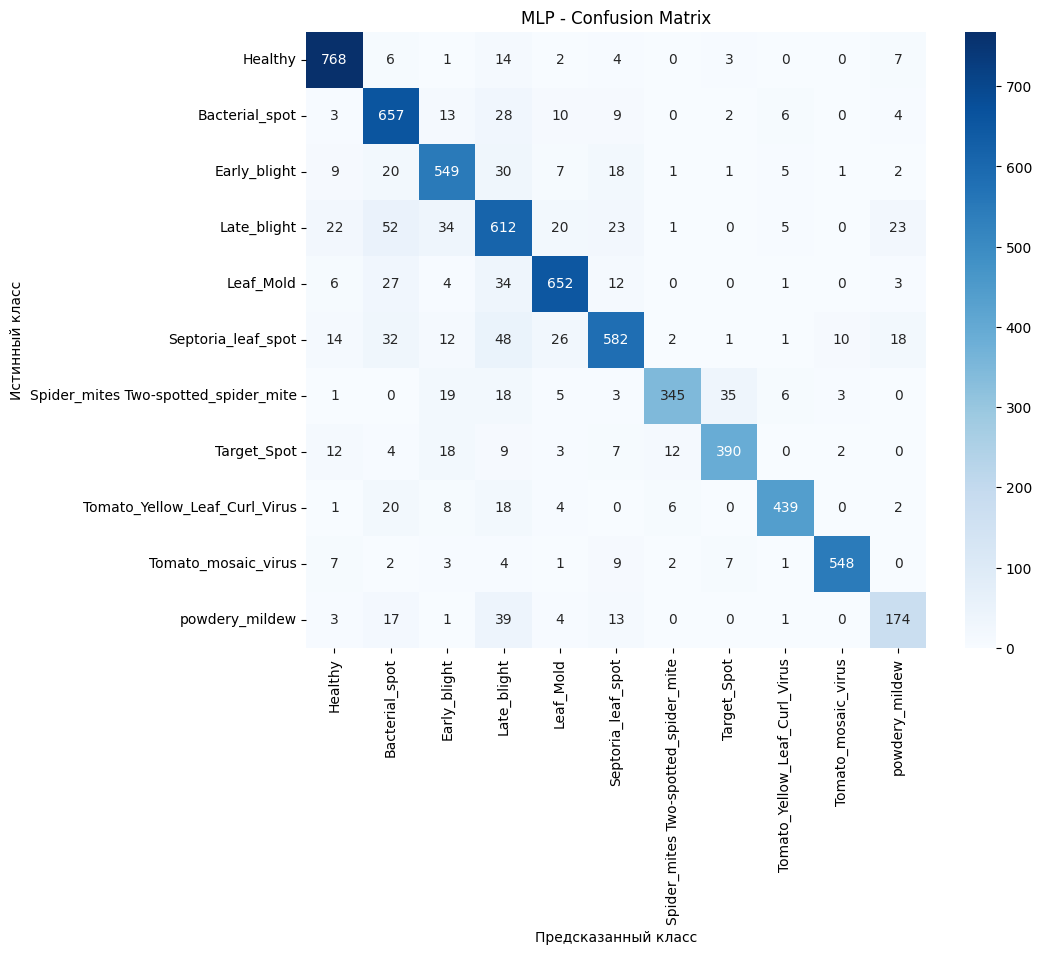


MLP Classification Report:
                                      precision    recall  f1-score   support

                             Healthy       0.91      0.95      0.93       805
                      Bacterial_spot       0.78      0.90      0.84       732
                        Early_blight       0.83      0.85      0.84       643
                         Late_blight       0.72      0.77      0.74       792
                           Leaf_Mold       0.89      0.88      0.89       739
                  Septoria_leaf_spot       0.86      0.78      0.82       746
Spider_mites Two-spotted_spider_mite       0.93      0.79      0.86       435
                         Target_Spot       0.89      0.85      0.87       457
       Tomato_Yellow_Leaf_Curl_Virus       0.94      0.88      0.91       498
                 Tomato_mosaic_virus       0.97      0.94      0.95       584
                      powdery_mildew       0.75      0.69      0.72       252

                            accura

In [ ]:
df = pd.read_csv(file_path_train)
X_train = df.drop("label", axis=1)
y_train = df["label"]

df = pd.read_csv(file_path_valid)
X_test = df.drop("label", axis=1)
y_test = df["label"]

# Обучение Random Forest
rf_all = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=2025)
rf_all.fit(X_train, y_train)
joblib.dump(rf_all, "/content/drive/My Drive/models/my_rf_all.pkl")
print("Random Forest Evaluation:")
evaluate_model_all(rf_all, X_test, y_test, "Random Forest")

# Обучение MLP
mlp_all = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=2025)
mlp_all.fit(X_train, y_train)
joblib.dump(mlp_all, "/content/drive/My Drive/models/my_mlp_all.pkl")
print("\nMLP Evaluation:")
evaluate_model_all(mlp_all, X_test, y_test, "MLP")

# Тест

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

from PIL import Image

In [ ]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
rf_binary = joblib.load("/content/drive/My Drive/models/my_rf_binary.pkl")
rf_sick = joblib.load("/content/drive/My Drive/models/my_rf_sick.pkl")

In [ ]:
classes = [
    "Bacterial_spot", "Early_blight", "Late_blight", "Leaf_Mold",
    "Septoria_leaf_spot", "Spider_mites Two-spotted_spider_mite",
    "Target_Spot", "Tomato_Yellow_Leaf_Curl_Virus", "Tomato_mosaic_virus",
    "powdery_mildew"
]

def classify_leaf(image):
    image_path = "/content/temp_leaf.jpg"
    image.save(image_path)

    features = extract_features(image_path)

    is_sick = rf_binary.predict([features])[0]

    if is_sick == 0:
        result = {"Диагноз": "Healthy"}
        return result
    else:
        y_proba = rf_sick.predict_proba([features])[0]
        predicted_class = np.argmax(y_proba)

        result = {
            "Диагноз": classes[predicted_class],
            "Вероятности": {cls: f"{prob:.2%}" for cls, prob in zip(classes, y_proba)}
        }
        return result

In [ ]:
iface = gr.Interface(
    fn=classify_leaf,
    inputs=gr.Image(type="pil", label="Загрузите изображение листа"),
    outputs=gr.JSON(label="Результат классификации"),
    title="Классификатор болезней листьев томата",
    description="Загрузите изображение листа томата, и модель определит, здоров он или болен."
)

iface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5732762cf1e279c764.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
